In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

In [3]:
data['time'] = pd.to_datetime(data['time'])

### 7. Compute mean, median, std, min, max, quartiles 

In [4]:
data.describe()

,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure
count,17544,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,2024-01-01 11:30:00,30.664689,43.707974,612.107045,12.572458,6.137454,96.054891,18.154799,74.586069,4.494921,202.288703,870.526813
min,2023-01-01 00:00:00,0.400000,0.500000,87.000000,0.000000,0.000000,9.000000,0.800000,9.000000,0.000000,2.000000,860.000000
25%,2023-07-02 17:45:00,17.500000,25.575000,314.000000,3.500000,3.500000,67.000000,13.800000,60.000000,2.500000,153.000000,868.200000
50%,2024-01-01 11:30:00,26.100000,38.400000,477.000000,9.500000,5.200000,93.000000,19.100000,79.000000,3.900000,180.000000,870.400000
75%,2024-07-02 05:15:00,39.000000,57.500000,764.000000,18.300000,7.400000,123.000000,22.300000,94.000000,5.600000,281.000000,872.800000
max,2024-12-31 23:00:00,164.400000,180.200000,3153.000000,107.300000,34.300000,226.000000,31.700000,100.000000,20.600000,360.000000,881.000000
std,NaN,19.408556,24.614492,421.671717,11.520046,4.086209,35.692174,5.896066,20.973804,2.831807,77.789930,3.355115


### 8. Plot histogram, KDE, boxplot

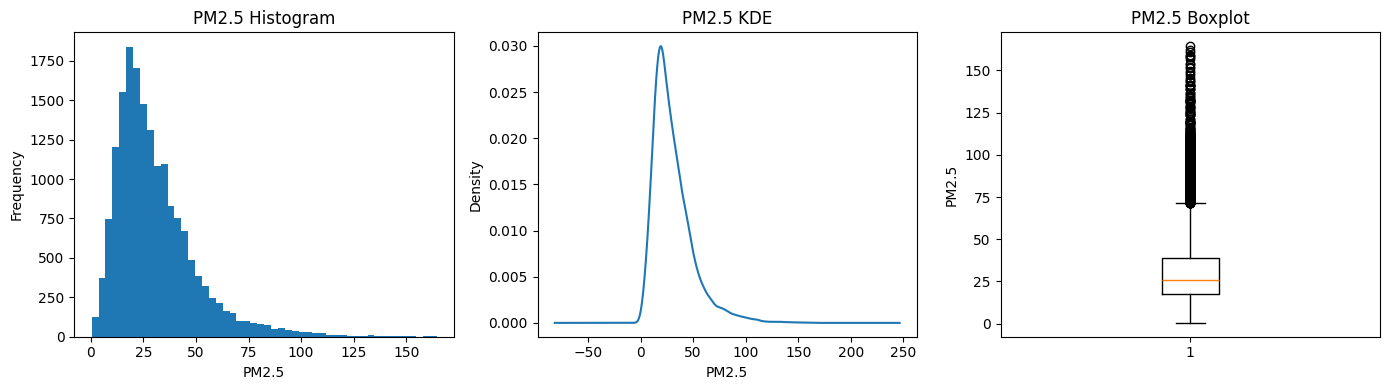

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histogram
axes[0].hist(data['pm2_5'], bins=50)
axes[0].set_title('PM2.5 Histogram')
axes[0].set_xlabel('PM2.5')
axes[0].set_ylabel('Frequency')

# KDE
data['pm2_5'].plot.kde(ax=axes[1])
axes[1].set_title('PM2.5 KDE')
axes[1].set_xlabel('PM2.5')

# Boxplot
axes[2].boxplot(data['pm2_5'])
axes[2].set_title('PM2.5 Boxplot')
axes[2].set_ylabel('PM2.5')

plt.tight_layout()
plt.show()

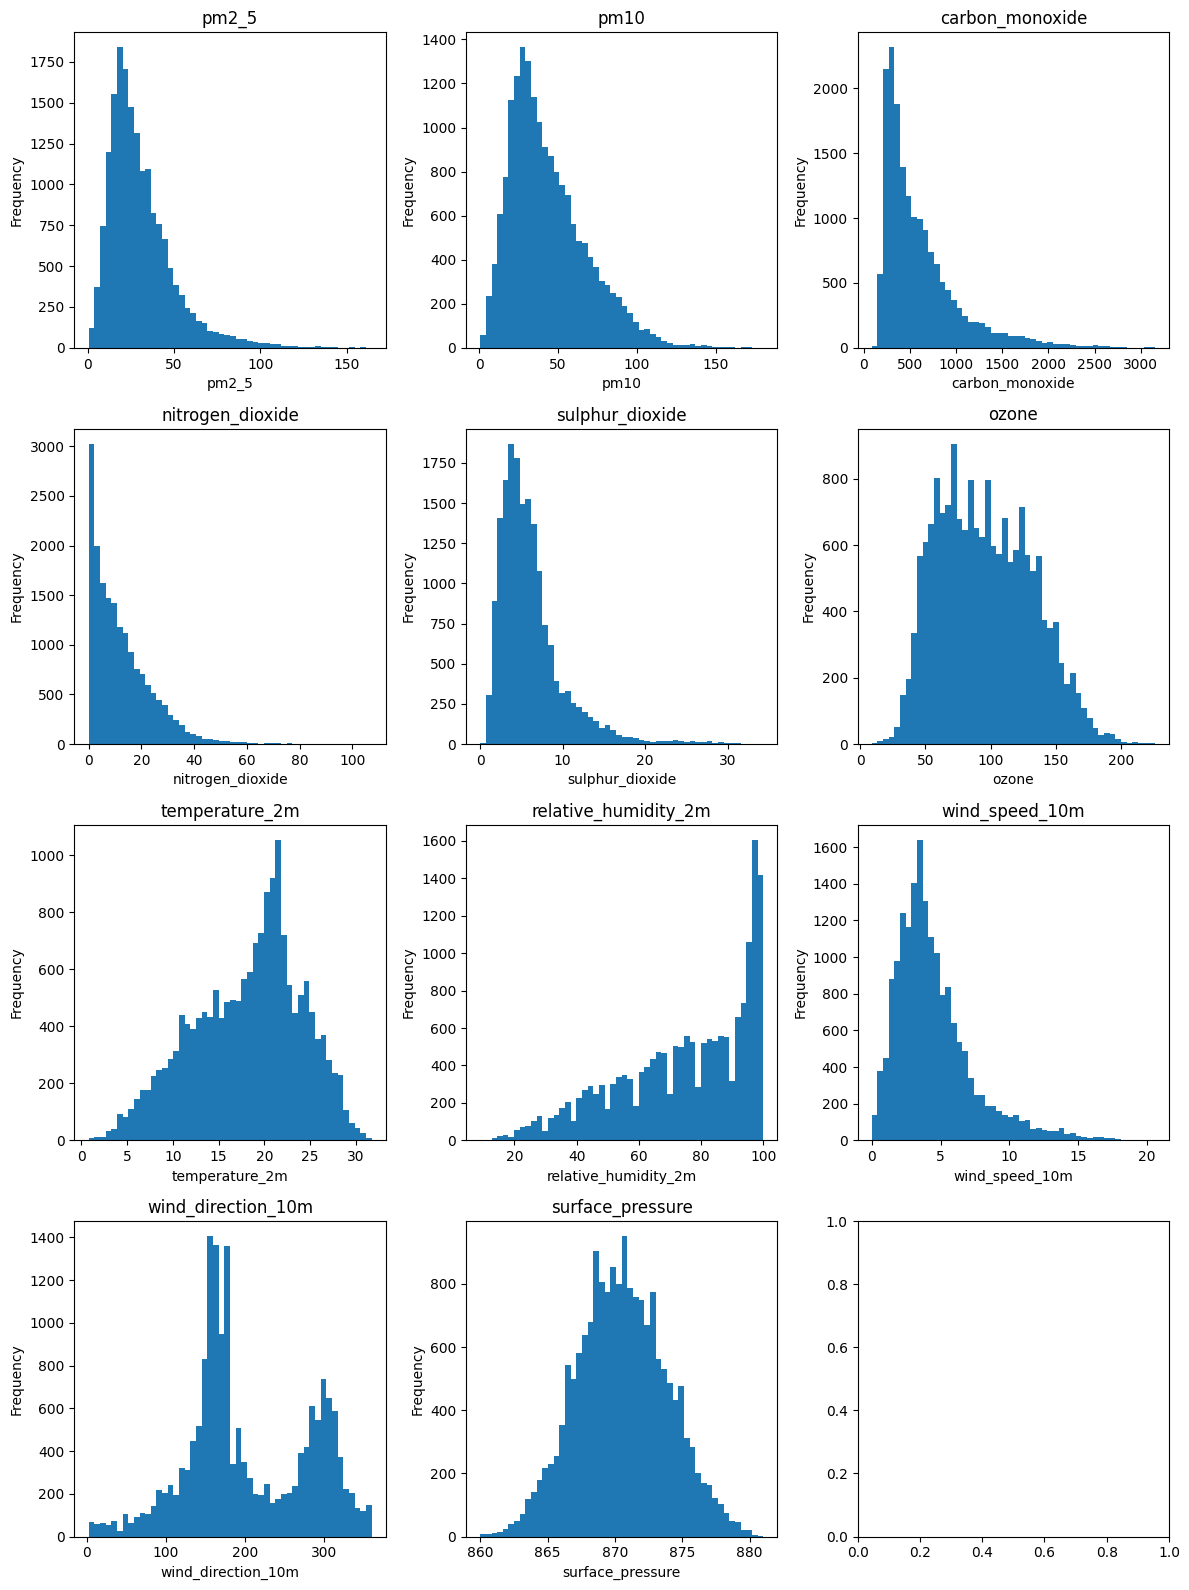

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
axes = axes.flatten()
cols = data.columns.tolist()
cols.remove('time')

for i in range (0, 11):
    axes[i].hist(data[cols[i]], bins=50)
    axes[i].set_title(f'{cols[i]}')
    axes[i].set_xlabel(cols[i])
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 9. Use IQR, Z-score, percentile analysis

In [15]:
# IQR
Q1 = data['pm2_5'].quantile(0.25)
Q3 = data['pm2_5'].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = data[(data['pm2_5'] < Q1 - 1.5*IQR) | (data['pm2_5'] > Q3 + 1.5*IQR)]
print(f"IQR Outliers: {len(iqr_outliers)} ({len(iqr_outliers)/len(data)*100:.2f}%)")

# Z-score
z_scores = (data['pm2_5'] - data['pm2_5'].mean()) / data['pm2_5'].std()
zscore_outliers = data[z_scores.abs() > 3]
print(f"Z-score Outliers: {len(zscore_outliers)} ({len(zscore_outliers)/len(data)*100:.2f}%)")

# Percentile
p1  = data['pm2_5'].quantile(0.01)
p99 = data['pm2_5'].quantile(0.99)
pct_outliers = data[(data['pm2_5'] < p1) | (data['pm2_5'] > p99)]
print(f"Percentile Outliers (1-99): {len(pct_outliers)} ({len(pct_outliers)/len(data)*100:.2f}%)")

IQR Outliers: 753 (4.29%)
Z-score Outliers: 327 (1.86%)
Percentile Outliers (1-99): 344 (1.96%)


### 10. Convert PM2.5 into AQI classes and analyze frequency

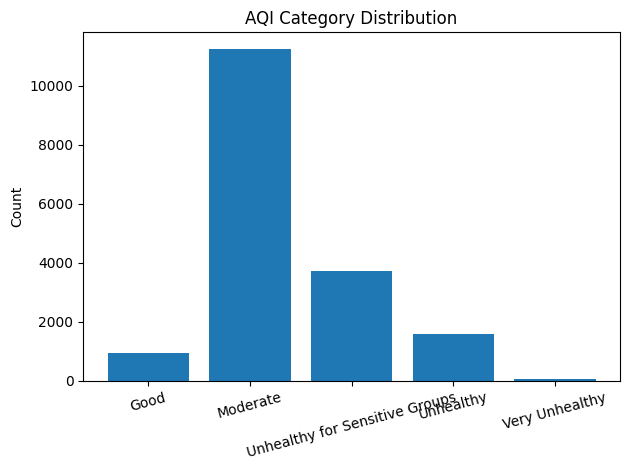

In [17]:
# this AQI classes is based on the global standard defined by the United States Environmental Protection Agency (US EPA)
def pm25_to_aqi_category(pm):
    if pm < 0:
        return 'Invalid concentration'
    elif pm <= 9.0:        
        return 'Good'
    elif pm <= 35.4:      
        return 'Moderate'
    elif pm <= 55.4:      
        return 'Unhealthy for Sensitive Groups'
    elif pm <= 125.4:     
        return 'Unhealthy'
    elif pm <= 225.4:     
        return 'Very Unhealthy'
    else:                 
        return 'Hazardous'

data['aqi_category'] = data['pm2_5'].apply(pm25_to_aqi_category)

order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
counts = data['aqi_category'].value_counts().reindex(order)

plt.bar(counts.index, counts.values)
plt.title('AQI Category Distribution')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 11. Analyze average PM2.5 by hour of day

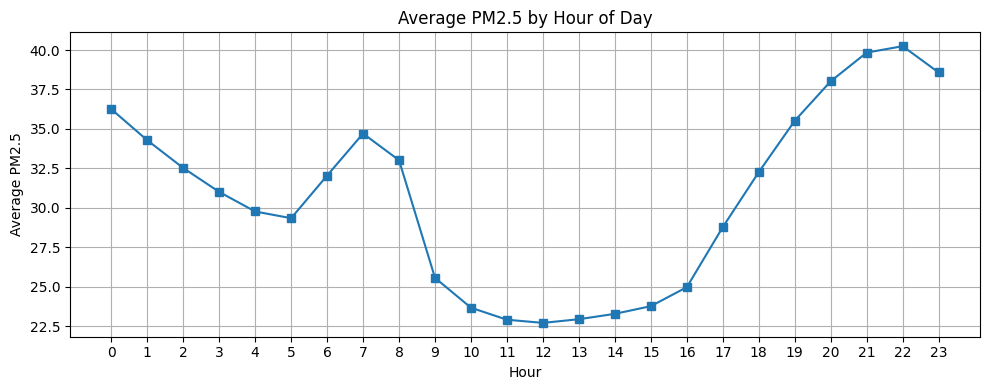

In [21]:
data['hour'] = data['time'].dt.hour
hourly_avg = data.groupby('hour')['pm2_5'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='s')
plt.title('Average PM2.5 by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average PM2.5')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

### 12. Compare weekday vs weekend pollution

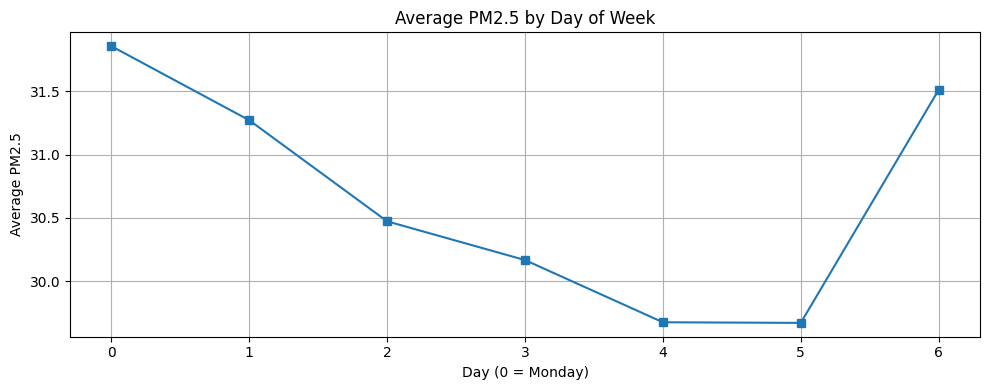

In [24]:
data['weekday'] = data['time'].dt.weekday
weekday_avg = data.groupby('weekday')['pm2_5'].mean()

plt.figure(figsize=(10, 4))
plt.plot(weekday_avg.index, weekday_avg.values, marker='s')
plt.title('Average PM2.5 by Day of Week')
plt.xlabel('Day (0 = Monday)')
plt.ylabel('Average PM2.5')
plt.xticks(range(0, 7))
plt.grid(True)
plt.tight_layout()
plt.show()